In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from google.colab import drive
from google.colab import files

In [87]:
file_path = 'https://www.dropbox.com/scl/fi/hsh5kfc52hv57pkjq3crp/scholastic_travel.csv?rlkey=lzmscfrwl7wfrlgxdhc469zss&st=0c5kf8b9&dl=1'
df_knn = pd.read_csv(file_path)

df_knn.head()

,ProgramCode,FromGrade,ToGrade,GroupState,IsNonAnnual,Days,TravelType,DepartureDate,ReturnDate,DepositDate,...,GroupGradeTypeLow,GroupGradeTypeHigh,GroupGradeType,MajorProgramCode,SingleGradeTripFlag,FPPtoSchoolenrollment,FPPtoPAX,NumofNonFPPPAX,SchoolSizeIndicator,RetainedLabel
0,HS,4,4,CA,0,1,A,1/14/11,1/14/11,8/30/10,...,K,Elementary,K->Elementary,H,1,0.063646,0.936508,4,L,Retained
1,HC,8,8,AZ,0,7,A,1/14/11,1/21/11,11/15/09,...,Middle,Middle,Middle->Middle,H,1,0.025882,0.880000,3,L,Retained
2,HD,8,8,FL,0,3,A,1/15/11,1/17/11,10/15/10,...,Middle,Middle,Middle->Middle,H,1,0.025131,0.888889,3,L,Retained
3,HN,9,12,Other,1,3,B,1/15/11,1/17/11,1/7/11,...,Undefined,Undefined,Undefined->Undefined,H,0,0.000000,1.000000,0,FIXED_NA,Churned
4,HD,6,8,FL,0,6,Other,1/16/11,1/21/11,9/30/10,...,Middle,Middle,Middle->Middle,H,0,0.112500,0.910112,8,M-L,Churned


#K-Nearest Neighbors
Build a K-Nearest Neighbors model to predict who will return the following year. Begin with a basic model with `ToGrade, Tuition, Days, TotalSchoolEnrollment as predictors and a K=20. Report the accuracy, precision, recall, and AUC for this model.`

Look through the data dictionary for factors that may lead to better predictions. Note that numeric rather than categorical data tend to work better for K-Nearest Neighbors. Add in predictors you think may be helpful and remove the predictors that do not seem to be adding much value to the model. Tune the model parameters by changing the hyperparameters for K-Nearest Neighbors (documentation linked below).

How does the evaluation metrics (accuracy, precision, etc.) change as you modify the predictors and tune the model? Keep a log of all the changes you try and report the predictors and tuning parameters along with the evaluation metrics in a table.

What are the factors and parameters that give you the best accuracy? Describe your approach and your findings, including a small table (no more than 5-10 rows) of the parameters you tried.

## Data exploration and pre-processing

In [88]:
df_knn.columns[df_knn.isnull().any()]

Index([], dtype='object')

In [89]:
df_knn.shape

(2389, 55)

In [90]:
df_knn["RetainedLabel"].value_counts()

,count
RetainedLabel,
Retained,1451
Churned,938


In [91]:
mapping = {'Retained': 0, 'Churned': 1}
df_knn['ChurnLabel'] = df_knn['RetainedLabel'].map(mapping)

In [92]:
df_knn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2389 entries, 0 to 2388
Data columns (total 56 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ProgramCode                     2389 non-null   object 
 1   FromGrade                       2389 non-null   int64  
 2   ToGrade                         2389 non-null   int64  
 3   GroupState                      2389 non-null   object 
 4   IsNonAnnual                     2389 non-null   int64  
 5   Days                            2389 non-null   int64  
 6   TravelType                      2389 non-null   object 
 7   DepartureDate                   2389 non-null   object 
 8   ReturnDate                      2389 non-null   object 
 9   DepositDate                     2389 non-null   object 
 10  SpecialPay                      2389 non-null   object 
 11  Tuition                         2389 non-null   int64  
 12  FRPActive                       23

In [93]:
df_knn["LastMeeting"]

,LastMeeting
0,8/12/10
1,8/27/10
2,9/13/10
3,1/1/10
4,8/24/10
...,...
2384,1/1/10
2385,10/7/10
2386,1/1/10
2387,9/16/10


In [94]:
date_cols = [
    "DepartureDate",
    "ReturnDate",
    "DepositDate",
    "EarlyRPL",
    "LatestRPL",
    "InitialSystemDate",
    "FirstMeeting",
    "LastMeeting"
]

for col in date_cols:
    df_knn[col] = pd.to_datetime(df_knn[col], format="%m/%d/%y", errors="coerce")

df_knn["days_to_departure"] = (df_knn["DepartureDate"] - df_knn["DepositDate"]).dt.days
df_knn["planning_window"] = (df_knn["DepartureDate"] - df_knn["InitialSystemDate"]).dt.days
df_knn["meeting_span"] = (df_knn["LastMeeting"] - df_knn["FirstMeeting"]).dt.days
df_knn["deposit_to_first_meeting"] = (df_knn["FirstMeeting"] - df_knn["DepositDate"]).dt.days

In [95]:
df_knn["ChurnLabel"]

,ChurnLabel
0,0
1,0
2,0
3,1
4,1
...,...
2384,1
2385,0
2386,0
2387,0


In [96]:
df_knn["grade_range"] = df_knn["ToGrade"] - df_knn["FromGrade"]

In [97]:
df_knn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2389 entries, 0 to 2388
Data columns (total 61 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   ProgramCode                     2389 non-null   object        
 1   FromGrade                       2389 non-null   int64         
 2   ToGrade                         2389 non-null   int64         
 3   GroupState                      2389 non-null   object        
 4   IsNonAnnual                     2389 non-null   int64         
 5   Days                            2389 non-null   int64         
 6   TravelType                      2389 non-null   object        
 7   DepartureDate                   2389 non-null   datetime64[ns]
 8   ReturnDate                      2389 non-null   datetime64[ns]
 9   DepositDate                     2389 non-null   datetime64[ns]
 10  SpecialPay                      2389 non-null   object        
 11  Tuit

## KNN Model

In [98]:
# Ensure features and labels are defined
features = ["ToGrade", "Tuition", "Days", "TotalSchoolEnrollment"]
X = df_knn[features]
y = df_knn["ChurnLabel"]

# This is the line that defines X_train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


KNN Classification Report:
               precision    recall  f1-score   support

    Retained       0.64      0.82      0.72       274
     Churned       0.61      0.37      0.46       204

    accuracy                           0.63       478
   macro avg       0.63      0.60      0.59       478
weighted avg       0.63      0.63      0.61       478

Area under ROC curve (AUC): 0.6599


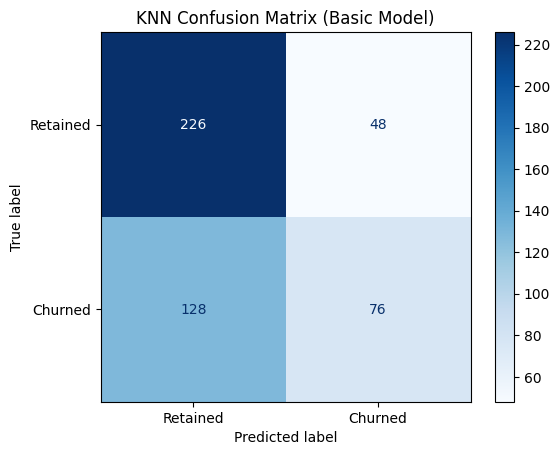

In [99]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Define the steps
steps = [
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=20))
]

# 2. Create and Fit the pipeline
pipeline = Pipeline(steps)
pipeline.fit(X_train, y_train)

# 3. Predict using the RAW X_test (The pipeline scales it for you!)
y_pred = pipeline.predict(X_test)
knn_y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

# 4. Evaluation
print("\nKNN Classification Report:\n",
      classification_report(y_test, y_pred, target_names=["Retained", "Churned"]))

print(f"Area under ROC curve (AUC): {roc_auc_score(y_test, knn_y_pred_proba):.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
# Added display_labels so you know which box is 'Churned'
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Retained", "Churned"])
disp.plot(cmap='Blues')
plt.title('KNN Confusion Matrix (Basic Model)') # Fixed the closing parenthesis here
plt.show()

## Adding PCA this time with all numeric columns only


KNN Classification Report:
               precision    recall  f1-score   support

    Retained       0.69      0.91      0.78       274
     Churned       0.78      0.46      0.58       204

    accuracy                           0.72       478
   macro avg       0.74      0.68      0.68       478
weighted avg       0.73      0.72      0.70       478

Area under ROC curve (AUC): 0.8060505223987406


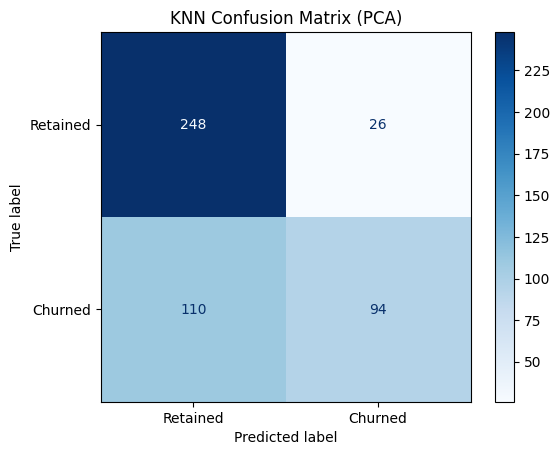

In [100]:
from sklearn.decomposition import PCA

X = df_knn.drop(columns=["RetainedLabel", "ChurnLabel"])
y = df_knn["ChurnLabel"]

X = X.select_dtypes(include=["number"])

# This is the line that defines X_train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. Define the steps
steps = [
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=.95)),
    ('knn', KNeighborsClassifier(n_neighbors=20))
]

# 2. Create and Fit the pipeline
pipeline = Pipeline(steps)
pipeline.fit(X_train, y_train)

# 3. Predict using the RAW X_test
# The pipeline handles the scaling for you automatically!
y_pred = pipeline.predict(X_test)
knn_y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

# 4. Evaluation
print("\nKNN Classification Report:\n",
      classification_report(y_test, y_pred, target_names=["Retained", "Churned"]))
print("Area under ROC curve (AUC):", roc_auc_score(y_test, knn_y_pred_proba))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Retained', 'Churned'])
disp.plot(cmap='Blues')
plt.title('KNN Confusion Matrix (PCA)')
plt.show()

## Randomized Grid Search with PCA


Best Parameters: {'knn__metric': 'manhattan', 'knn__n_neighbors': 64, 'knn__weights': 'distance', 'pca__n_components': 0.95}
Test ROC-AUC: 0.8176

Classification Report:

              precision    recall  f1-score   support

    Retained       0.68      0.92      0.79       274
     Churned       0.81      0.43      0.56       204

    accuracy                           0.71       478
   macro avg       0.74      0.67      0.67       478
weighted avg       0.74      0.71      0.69       478



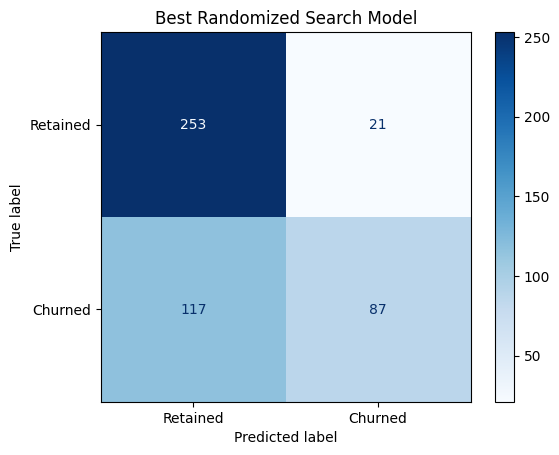

In [101]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay
)
from scipy.stats import randint
import matplotlib.pyplot as plt

# 1. Define Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA()),
    ('knn', KNeighborsClassifier())
])

# 2. Parameter distributions
param_dist = {
    'pca__n_components': [0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 0.98],
    'knn__n_neighbors': randint(3, 75),
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan', 'minkowski']
}


random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring="roc_auc",
    refit='roc_auc',   # model selected based on ROC-AUC
    n_jobs=-1,
    random_state=42
)

# 4. Fit
random_search.fit(X_train, y_train)

# 5. Best model
best_model = random_search.best_estimator_

# 6. Predictions
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

# 7. Evaluation
print(f"Best Parameters: {random_search.best_params_}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Retained", "Churned"]))

# 8. Confusion Matrix
disp = ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    display_labels=["Retained", "Churned"],
    cmap="Blues"
)

plt.title("Best Randomized Search Model")
plt.show()

## Manually Choosing Features, Grid Search

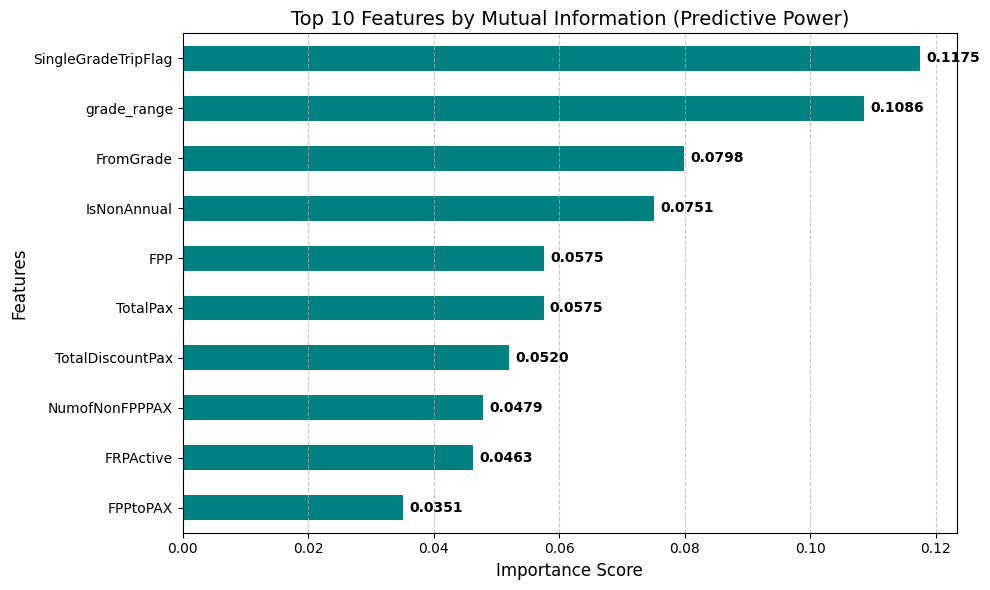

In [102]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_selection import mutual_info_classif

# --- 1. Calculate & Sort (From previous steps) ---
importances = mutual_info_classif(X_train, y_train, random_state=42)
feat_importances = pd.Series(importances, index=X_train.columns)
feat_importances_sorted = feat_importances.sort_values(ascending=False)

# --- 2. Select the Top 10 ---
top_10_features = feat_importances_sorted.head(10)
top_features_list = top_10_features.index.tolist() # Your list for later use

# --- 3. Create the Plot ---
plt.figure(figsize=(10, 6))
# Using barh (horizontal) is great for long feature names
top_10_features.plot(kind='barh', color='teal')

# --- 4. Add labels and title ---
plt.title('Top 10 Features by Mutual Information (Predictive Power)', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)

# --- 5. Invert y-axis & Grid ---
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)

# --- 6. Add Value Labels (Optional but helpful) ---
for i, v in enumerate(top_10_features):
    plt.text(v + 0.001, i, f'{v:.4f}', color='black', va='center', fontweight='bold')

# --- 7. Show/Save ---
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

# Now you can use this for your model:
# X_train_selected = X_train[top_features_list]

In [103]:
X = df_knn[top_features_list]
y = df_knn["ChurnLabel"]

# Re-run your train_test_split with this subset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Best Parameters: {'knn__metric': 'euclidean', 'knn__n_neighbors': 47, 'knn__weights': 'uniform'}
Test ROC-AUC: 0.8194

Classification Report:

              precision    recall  f1-score   support

    Retained       0.77      0.85      0.81       274
     Churned       0.76      0.66      0.71       204

    accuracy                           0.77       478
   macro avg       0.77      0.75      0.76       478
weighted avg       0.77      0.77      0.77       478



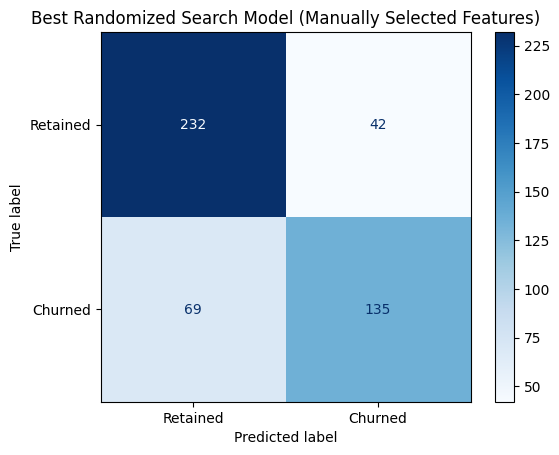

In [104]:
# 1. Define simpler pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

# 2. Adjust parameter distribution (No PCA parameters needed!)
param_dist = {
    'knn__n_neighbors': randint(3, 75),
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

# 3. Randomized Search focusing on ROC-AUC
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42
)

best_model = random_search.fit(X_train, y_train)

# 6. Predictions
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

# 7. Evaluation
print(f"Best Parameters: {random_search.best_params_}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Retained", "Churned"]))

# 8. Confusion Matrix
disp = ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    display_labels=["Retained", "Churned"],
    cmap="Blues"
)

plt.title("Best Randomized Search Model (Manually Selected Features)")
plt.show()

# Mutual Information Features and GridSearch (not random)

Best Parameters: {'knn__metric': 'euclidean', 'knn__n_neighbors': 41, 'knn__weights': 'uniform'}
Test ROC-AUC: 0.8172

Classification Report:

              precision    recall  f1-score   support

    Retained       0.77      0.85      0.81       274
     Churned       0.76      0.66      0.71       204

    accuracy                           0.77       478
   macro avg       0.77      0.75      0.76       478
weighted avg       0.77      0.77      0.77       478



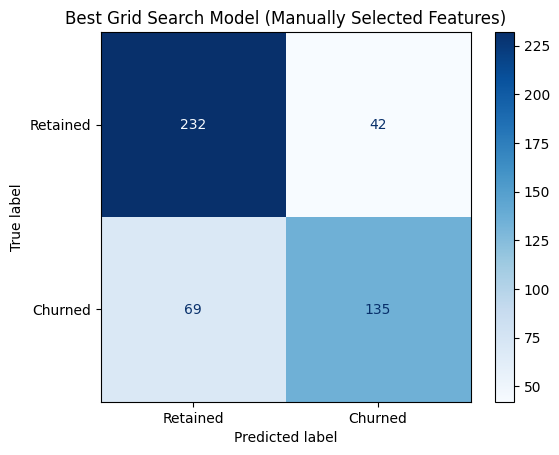

In [105]:
from sklearn.model_selection import GridSearchCV

# 1. Define simpler pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

# 2. Define exact grid (Replace randint with a list of values)
# For KNN, it is often best to test odd numbers to avoid ties
param_grid = {
    'knn__n_neighbors': [3, 5, 11, 21, 31, 41, 51, 61, 71],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

# 3. Grid Search focusing on ROC-AUC
# Note: Removed n_iter and random_state as they aren't used in GridSearchCV
grid_search = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

# 4. Fit the grid search
grid_search.fit(X_train, y_train)

# 5. Extract the best model
best_model = grid_search.best_estimator_

# 6. Predictions
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

# 7. Evaluation
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Retained", "Churned"]))

# 8. Confusion Matrix
disp = ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    display_labels=["Retained", "Churned"],
    cmap="Blues"
)

plt.title("Best Grid Search Model (Manually Selected Features)")
plt.show()